# Visual Baseline — SVM on HOG + Color Histogram Features

**Project:** Avis — Agentic AI Birdfeeder  
**Course:** CS 450 Introduction to AI, SDSU Spring 2026  
**Phase:** 3 — Baseline Models  
**PR:** #14 `feature/phase-3-visual-baseline`

## Goal

Establish the visual classification performance floor using a Support Vector Machine (SVM)
classifier on HOG (Histogram of Oriented Gradients) + color histogram features extracted
from NABirds images.

This is the required course baseline before pretrained models (EfficientNet-B0, Phase 4)
are introduced. Results set the bar that fine-tuning must beat.

## Why HOG + Color Histogram for SVM?

The vision pipeline (`src/vision/preprocess.py`) produces `(224, 224, 3)` float32 arrays —
fixed size, ready for feature extraction. Two complementary feature types are combined:

- **HOG** — captures edge orientations and shape structure. Strong for distinguishing
  bird silhouettes, postures, and body proportions (woodpecker vs sparrow vs hummingbird).
- **Color histogram** — captures plumage color distribution per channel. Helps distinguish
  species with similar shapes but different coloring (HOFI red breast vs WCSP black/white
  head vs LEGO yellow).

Combining both gives the SVM richer signal than either alone, at negligible extra compute cost.

## Why SVM?

SVMs with RBF kernels find maximum-margin decision boundaries in high-dimensional feature
spaces. They generalize well with limited training data — important here given our
smallest classes have only 36 training images. SVMs are the standard visual baseline
in ML coursework before deep learning is introduced.

## Thin-Data Species Note

All 19 species have reasonable visual data (36–261 training images) thanks to NABirds.
No species are flagged as critically thin for visual — unlike audio where BLPH had 1
training file. However SOSP (36 train), OCWA (68 train), and WREN (68 train) are on
the smaller end and may show weaker per-class metrics.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from PIL import Image
from skimage.feature import hog
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=UserWarning)

# ── Project root on sys.path ──────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder


In [2]:
# ── Load configs ──────────────────────────────────────────────────────────────
with open(PROJECT_ROOT / "configs" / "thresholds.yaml") as f:
    thresholds = yaml.safe_load(f)

with open(PROJECT_ROOT / "configs" / "paths.yaml") as f:
    paths_cfg = yaml.safe_load(f)

# Vision preprocessing parameters — match src/vision/preprocess.py exactly
INPUT_WIDTH:  int = thresholds["vision"]["input_width"]   # 224
INPUT_HEIGHT: int = thresholds["vision"]["input_height"]  # 224

# HOG parameters
HOG_ORIENTATIONS:  int = 9     # number of gradient orientation bins
HOG_PIXELS_PER_CELL = (8, 8)   # spatial resolution of each HOG cell
HOG_CELLS_PER_BLOCK = (2, 2)   # block normalisation window

# Color histogram parameters
COLOR_BINS: int = 32           # histogram bins per channel (R, G, B)
                                # 32 bins captures plumage color well without
                                # overfitting to lighting variation

# Split CSV paths
SPLITS_DIR   = PROJECT_ROOT / paths_cfg["datasets"].get("splits", "data/splits")
NABIRDS_DIR  = PROJECT_ROOT / paths_cfg["datasets"].get("nabirds_raw", "data/raw/nabirds")

# SVM hyperparameter candidates — tuned via val set
C_CANDIDATES = [0.1, 1.0, 10.0, 100.0]

# Smaller-data species — note in analysis
SMALLER_SPECIES = {"SOSP", "OCWA", "WREN"}

# ── Ensure output directories exist ───────────────────────────────────────────
RESULTS_DIR = PROJECT_ROOT / "notebooks" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input size     : {INPUT_WIDTH}x{INPUT_HEIGHT}")
print(f"HOG orientations: {HOG_ORIENTATIONS}")
print(f"Color bins     : {COLOR_BINS} per channel")
print(f"Splits dir     : {SPLITS_DIR}")
print(f"C candidates   : {C_CANDIDATES}")

Input size     : 224x224
HOG orientations: 9
Color bins     : 32 per channel
Splits dir     : C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder\data\splits
C candidates   : [0.1, 1.0, 10.0, 100.0]


## 2. HOG + Color Histogram Feature Extraction

In [3]:
def extract_visual_features(
    image_path: Path,
    width: int = INPUT_WIDTH,
    height: int = INPUT_HEIGHT,
    hog_orientations: int = HOG_ORIENTATIONS,
    hog_pixels_per_cell: tuple = HOG_PIXELS_PER_CELL,
    hog_cells_per_block: tuple = HOG_CELLS_PER_BLOCK,
    color_bins: int = COLOR_BINS,
) -> np.ndarray:
    """
    Extract a fixed-length HOG + color histogram feature vector from an image file.

    Pipeline:
        1. Load image as RGB uint8 via PIL (matches src/vision/preprocess.load_image)
        2. Resize to (224, 224) with BILINEAR interpolation (matches preprocess.resize)
        3. Extract HOG features from grayscale version — captures shape/edge structure
        4. Extract color histogram per RGB channel — captures plumage color distribution
        5. Concatenate HOG + color features into a single 1-D vector

    HOG feature size:
        With 224x224 input, 8x8 pixels/cell, 2x2 cells/block, 9 orientations:
        blocks_per_row = (224/8 - 1) = 27
        feature_size = 27 * 27 * 2 * 2 * 9 = 26244

    Color histogram size:
        32 bins × 3 channels = 96

    Total feature vector: 26244 + 96 = 26340 dimensions

    Args:
        image_path: Path to image file (JPEG from NABirds).
        width, height: Target resize dimensions. Default 224x224.
        hog_orientations: Number of gradient orientation bins.
        hog_pixels_per_cell: (rows, cols) pixels per HOG cell.
        hog_cells_per_block: (rows, cols) cells per normalisation block.
        color_bins: Histogram bins per RGB channel.

    Returns:
        1-D float32 array of shape (26340,).
    """
    # Load and resize — PIL BILINEAR matches src/vision/preprocess.resize()
    img = Image.open(image_path).convert("RGB")
    img = img.resize((width, height), resample=Image.BILINEAR)
    img_array = np.array(img, dtype=np.uint8)  # (H, W, 3) uint8

    # ── HOG features ──────────────────────────────────────────────────────────
    # Convert to grayscale for HOG — shape edges are channel-independent
    gray = np.array(img.convert("L"), dtype=np.float32) / 255.0  # (H, W)

    hog_feats = hog(
        gray,
        orientations=hog_orientations,
        pixels_per_cell=hog_pixels_per_cell,
        cells_per_block=hog_cells_per_block,
        block_norm="L2-Hys",
        feature_vector=True,
    )  # 1-D float64 array

    # ── Color histogram features ───────────────────────────────────────────────
    # One histogram per RGB channel, normalised to sum to 1.
    # Normalisation makes features lighting-invariant — a bright vs dim photo
    # of the same bird produces similar histograms.
    color_feats = []
    for channel in range(3):  # R, G, B
        hist, _ = np.histogram(img_array[:, :, channel], bins=color_bins, range=(0, 256))
        hist = hist.astype(np.float32)
        hist /= (hist.sum() + 1e-7)  # normalise, guard against zero-sum
        color_feats.append(hist)

    color_feats = np.concatenate(color_feats)  # (color_bins * 3,) = (96,)

    # ── Concatenate ───────────────────────────────────────────────────────────
    feature_vector = np.concatenate([hog_feats, color_feats]).astype(np.float32)
    return feature_vector


# ── Sanity check on one file ──────────────────────────────────────────────────
_sample_files = list((NABIRDS_DIR / "images").glob("*/*.jpg"))
if _sample_files:
    _feat = extract_visual_features(_sample_files[0])
    print(f"Feature vector shape : {_feat.shape}")
    print(f"  HOG component      : 26244 dims (shape/edge features)")
    print(f"  Color component    : {COLOR_BINS * 3} dims (plumage color features)")
    print(f"  Range              : [{_feat.min():.4f}, {_feat.max():.4f}]")
    print(f"  Sample file        : {_sample_files[0].name}")
else:
    print("WARNING: No JPG files found. Check NABIRDS_DIR path.")

Feature vector shape : (26340,)
  HOG component      : 26244 dims (shape/edge features)
  Color component    : 96 dims (plumage color features)
  Range              : [0.0000, 0.6613]
  Sample file        : 01f53d6bf5e449438d2bb79e0854bca4.jpg


## 3. Load Splits and Extract Features

In [4]:
def load_split(csv_path: Path) -> pd.DataFrame:
    """Load a split CSV and return rows where the image file exists on disk."""
    df = pd.read_csv(csv_path)
    # Column is 'file_path' (absolute path from generate_splits.py)
    df["filepath"] = df["file_path"].apply(Path)
    exists = df["filepath"].apply(lambda p: p.exists())
    missing = (~exists).sum()
    if missing:
        print(f"  WARNING: {missing} files in {csv_path.name} not found on disk — skipping")
    return df[exists].reset_index(drop=True)


train_df = load_split(SPLITS_DIR / "visual_train.csv")
val_df   = load_split(SPLITS_DIR / "visual_val.csv")
test_df  = load_split(SPLITS_DIR / "visual_test.csv")

print(f"Train : {len(train_df)} files across {train_df['species_code'].nunique()} species")
print(f"Val   : {len(val_df)} files across {val_df['species_code'].nunique()} species")
print(f"Test  : {len(test_df)} files across {test_df['species_code'].nunique()} species")

Train : 2003 files across 19 species
Val   : 667 files across 19 species
Test  : 672 files across 19 species


In [5]:
def extract_features_for_split(df: pd.DataFrame, split_name: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Extract HOG + color histogram features for every image in a split DataFrame.

    Returns:
        X: float32 array of shape (n_samples, feature_dim)
        y: string array of species codes, shape (n_samples,)
    """
    X_list, y_list = [], []
    failed = 0
    total = len(df)

    for i, (_, row) in enumerate(df.iterrows()):
        if i % 200 == 0:
            print(f"  {split_name}: {i}/{total}...")
        try:
            feats = extract_visual_features(Path(row["filepath"]))
            X_list.append(feats)
            y_list.append(row["species_code"])
        except Exception as exc:
            failed += 1
            print(f"  WARN: failed on {Path(row['filepath']).name}: {exc}")

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list)
    print(f"{split_name:6s}: X={X.shape}  y={y.shape}  failed={failed}")
    return X, y


print("Extracting HOG + color features — this takes 5-10 minutes for 3342 images...")
X_train, y_train = extract_features_for_split(train_df, "train")
X_val,   y_val   = extract_features_for_split(val_df,   "val")
X_test,  y_test  = extract_features_for_split(test_df,  "test")
print("Done.")

Extracting HOG + color features — this takes 5-10 minutes for 3342 images...
  train: 0/2003...
  train: 200/2003...
  train: 400/2003...
  train: 600/2003...
  train: 800/2003...
  train: 1000/2003...
  train: 1200/2003...
  train: 1400/2003...
  train: 1600/2003...
  train: 1800/2003...
  train: 2000/2003...
train : X=(2003, 26340)  y=(2003,)  failed=0
  val: 0/667...
  val: 200/667...
  val: 400/667...
  val: 600/667...
val   : X=(667, 26340)  y=(667,)  failed=0
  test: 0/672...
  test: 200/672...
  test: 400/672...
  test: 600/672...
test  : X=(672, 26340)  y=(672,)  failed=0
Done.


## 4. Feature Scaling

In [6]:
# SVM with RBF kernel is sensitive to feature scale — StandardScaler is required.
# Fit on train only, transform val and test with the same statistics.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print(f"Classes ({len(le.classes_)}): {list(le.classes_)}")
print(f"Feature dim after scaling: {X_train_scaled.shape[1]}")

Classes (19): ['AMCR', 'AMRO', 'ANHU', 'BLPH', 'DOWO', 'EUST', 'HOFI', 'HOORI', 'HOSP', 'LEGO', 'MOCH', 'MODO', 'OCWA', 'SOSP', 'SPTO', 'WBNU', 'WCSP', 'WREN', 'YRUM']
Feature dim after scaling: 26340


## 5. C Parameter Selection on Validation Set

  C=   0.1  val accuracy=0.1304
  C=   1.0  val accuracy=0.1979
  C=  10.0  val accuracy=0.2069
  C= 100.0  val accuracy=0.2069

Best C = 10.0  (val accuracy = 0.2069)


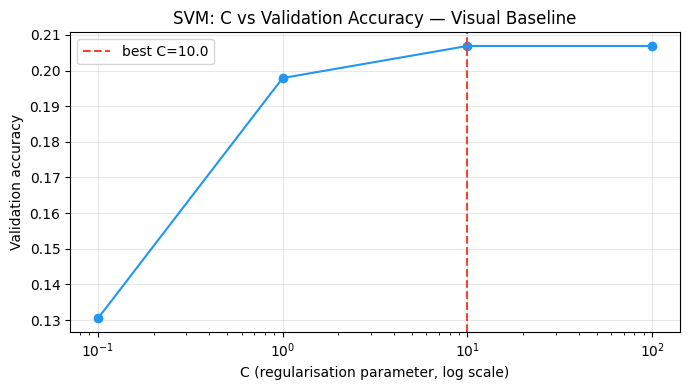

Saved: notebooks/results/visual_baseline_c_selection.png


In [7]:
# C controls the SVM regularisation strength.
# Small C: wider margin, more misclassifications allowed (underfitting risk)
# Large C: narrow margin, fewer misclassifications (overfitting risk)
# We select C on the val set before final evaluation on test.

val_scores: dict[float, float] = {}

for C in C_CANDIDATES:
    svm = SVC(kernel="rbf", C=C, gamma="scale", random_state=42)
    svm.fit(X_train_scaled, y_train_enc)
    acc = svm.score(X_val_scaled, y_val_enc)
    val_scores[C] = acc
    print(f"  C={C:6.1f}  val accuracy={acc:.4f}")

best_C = max(val_scores, key=val_scores.get)
print(f"\nBest C = {best_C}  (val accuracy = {val_scores[best_C]:.4f})")

# ── Plot C vs accuracy ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(list(val_scores.keys()), list(val_scores.values()), marker="o", color="#2196F3")
ax.axvline(best_C, color="#F44336", linestyle="--", label=f"best C={best_C}")
ax.set_xlabel("C (regularisation parameter, log scale)")
ax.set_ylabel("Validation accuracy")
ax.set_title("SVM: C vs Validation Accuracy — Visual Baseline")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "visual_baseline_c_selection.png", dpi=120)
plt.show()
print("Saved: notebooks/results/visual_baseline_c_selection.png")

## 6. Train Final Model and Evaluate on Test Set

In [8]:
# Retrain on train + val combined with best C, then evaluate on held-out test set.
X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval  = np.concatenate([y_train_enc, y_val_enc])

svm_final = SVC(kernel="rbf", C=best_C, gamma="scale", random_state=42)
svm_final.fit(X_trainval, y_trainval)

y_pred_enc = svm_final.predict(X_test_scaled)
y_pred     = le.inverse_transform(y_pred_enc)

test_accuracy = svm_final.score(X_test_scaled, y_test_enc)
print(f"Test accuracy (C={best_C}): {test_accuracy:.4f}")

Test accuracy (C=10.0): 0.2128


## 7. Per-Class Metrics

In [9]:
report = classification_report(
    y_test, y_pred,
    labels=le.classes_,
    target_names=le.classes_,
    zero_division=0,
)
print(report)

print("\nNote: SOSP, OCWA, WREN have smaller training sets (36-68 images).")
print("Their per-class metrics may be lower but are not critically thin.")

              precision    recall  f1-score   support

        AMCR       0.00      0.00      0.00        24
        AMRO       0.23      0.38      0.29        47
        ANHU       0.26      0.36      0.30        45
        BLPH       0.00      0.00      0.00        24
        DOWO       0.81      0.81      0.81        16
        EUST       0.16      0.28      0.20        61
        HOFI       0.20      0.04      0.07        47
       HOORI       0.00      0.00      0.00        33
        HOSP       0.13      0.06      0.09        47
        LEGO       0.00      0.00      0.00        39
        MOCH       0.50      0.04      0.08        24
        MODO       0.00      0.00      0.00        24
        OCWA       0.00      0.00      0.00        23
        SOSP       0.00      0.00      0.00        12
        SPTO       0.00      0.00      0.00        24
        WBNU       0.00      0.00      0.00        24
        WCSP       0.24      0.10      0.14        48
        WREN       0.00    

## 8. Confusion Matrix

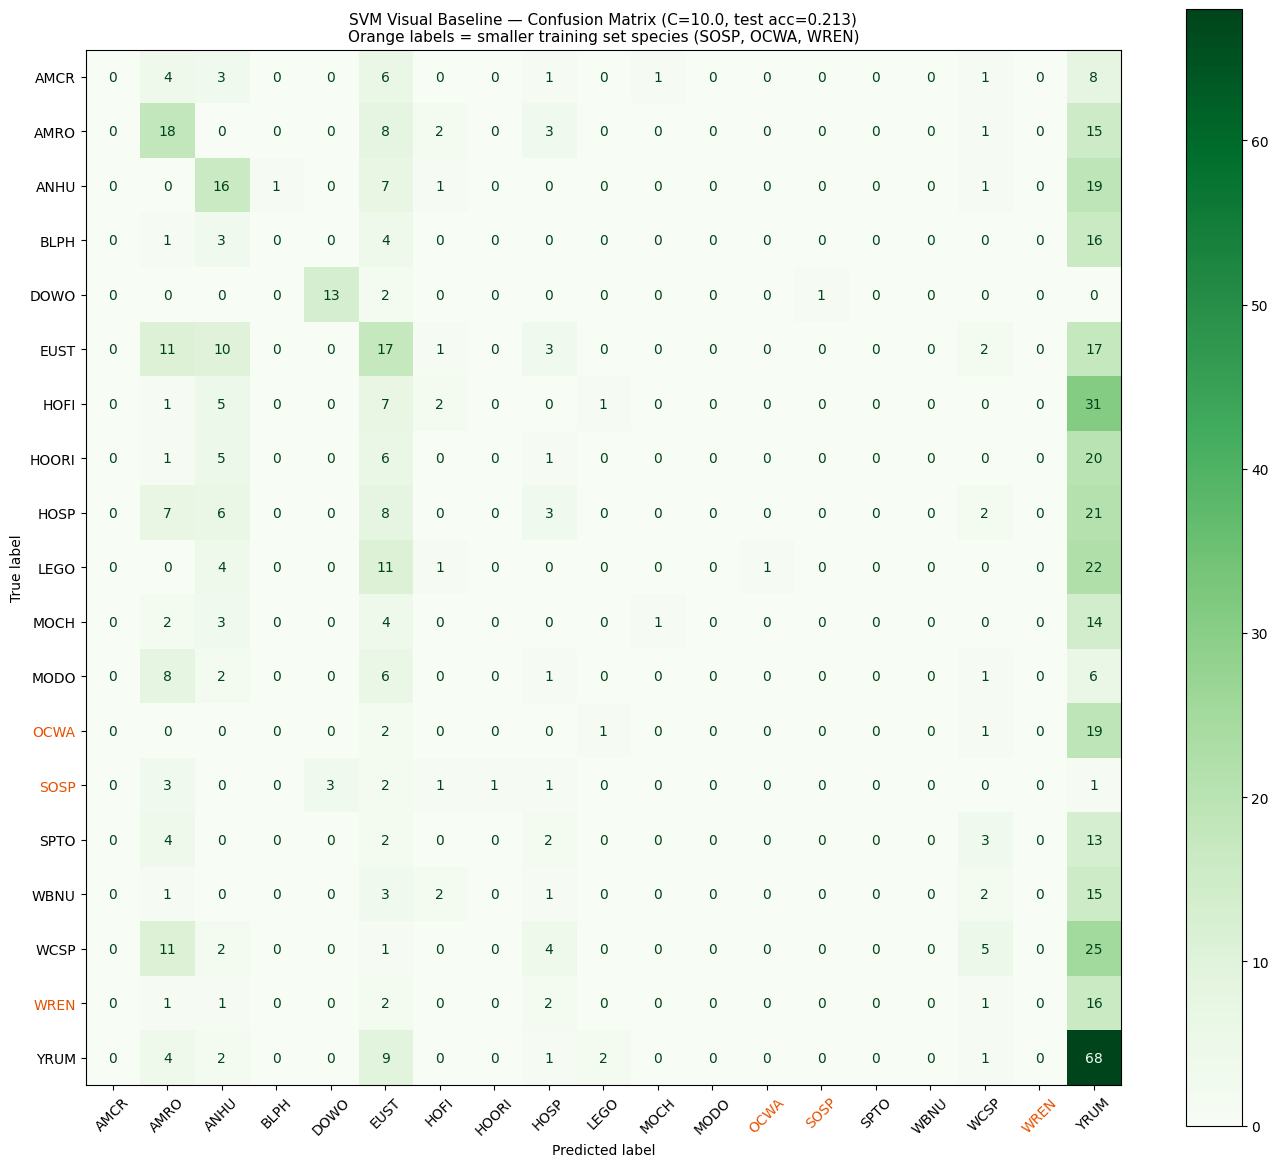

Saved: notebooks/results/visual_baseline_confusion_matrix.png


In [10]:
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap="Greens", xticks_rotation=45)

# Outline smaller-data species in orange
smaller_indices = [i for i, c in enumerate(le.classes_) if c in SMALLER_SPECIES]
for idx in smaller_indices:
    ax.get_xticklabels()[idx].set_color("#E65100")
    ax.get_yticklabels()[idx].set_color("#E65100")

ax.set_title(
    f"SVM Visual Baseline — Confusion Matrix (C={best_C}, test acc={test_accuracy:.3f})\n"
    "Orange labels = smaller training set species (SOSP, OCWA, WREN)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "visual_baseline_confusion_matrix.png", dpi=120)
plt.show()
print("Saved: notebooks/results/visual_baseline_confusion_matrix.png")

## 9. Per-Class F1 Score

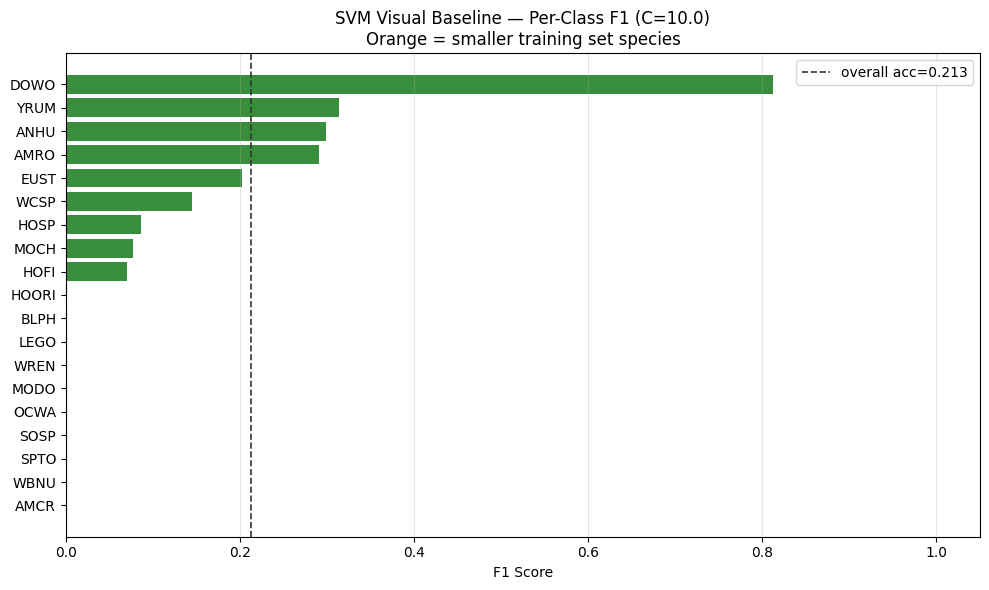

Saved: notebooks/results/visual_baseline_f1_per_class.png


In [11]:
f1_per_class = f1_score(y_test, y_pred, labels=le.classes_, average=None, zero_division=0)
f1_df = pd.DataFrame({"species": le.classes_, "f1": f1_per_class})
f1_df = f1_df.sort_values("f1", ascending=True)

colors = ["#E65100" if s in SMALLER_SPECIES else "#388E3C" for s in f1_df["species"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(f1_df["species"], f1_df["f1"], color=colors)
ax.axvline(test_accuracy, color="#333", linestyle="--", linewidth=1.2,
           label=f"overall acc={test_accuracy:.3f}")
ax.set_xlabel("F1 Score")
ax.set_title(f"SVM Visual Baseline — Per-Class F1 (C={best_C})\nOrange = smaller training set species")
ax.set_xlim(0, 1.05)
ax.legend()
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "visual_baseline_f1_per_class.png", dpi=120)
plt.show()
print("Saved: notebooks/results/visual_baseline_f1_per_class.png")

## 10. Baseline Summary

In [12]:
macro_f1    = f1_score(y_test, y_pred, average="macro",    zero_division=0)
weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("=" * 55)
print("  SVM VISUAL BASELINE — FINAL RESULTS")
print("=" * 55)
print(f"  Best C                : {best_C}")
print(f"  Kernel                : RBF (gamma=scale)")
print(f"  Feature vector size   : {X_train.shape[1]}  (HOG + color histogram)")
print(f"    HOG                 : 26244 dims")
print(f"    Color histogram     : {COLOR_BINS * 3} dims ({COLOR_BINS} bins x 3 channels)")
print(f"  Train+val samples     : {len(X_trainval)}")
print(f"  Test samples          : {len(X_test)}")
print(f"  Species (test)        : {len(le.classes_)}")
print(f"  Test accuracy         : {test_accuracy:.4f}")
print(f"  Macro F1              : {macro_f1:.4f}")
print(f"  Weighted F1           : {weighted_f1:.4f}")
print("=" * 55)
print()
print("Audio KNN baseline (PR #13) for comparison:")
print("  Test accuracy : 0.3023")
print("  Macro F1      : 0.1913")
print()
print("This baseline will be compared against EfficientNet fine-tuning in Phase 4.")
print("Target: EfficientNet macro F1 > SVM macro F1 on the same test split.")

  SVM VISUAL BASELINE — FINAL RESULTS
  Best C                : 10.0
  Kernel                : RBF (gamma=scale)
  Feature vector size   : 26340  (HOG + color histogram)
    HOG                 : 26244 dims
    Color histogram     : 96 dims (32 bins x 3 channels)
  Train+val samples     : 2670
  Test samples          : 672
  Species (test)        : 19
  Test accuracy         : 0.2128
  Macro F1              : 0.1208
  Weighted F1           : 0.1427

Audio KNN baseline (PR #13) for comparison:
  Test accuracy : 0.3023
  Macro F1      : 0.1913

This baseline will be compared against EfficientNet fine-tuning in Phase 4.
Target: EfficientNet macro F1 > SVM macro F1 on the same test split.


## 11. Save Baseline Model

Persist the trained SVM and scaler to `models/baselines/` so Phase 4 can
load them for direct comparison without re-running this notebook.

In [13]:
import pickle

MODELS_DIR = PROJECT_ROOT / "models" / "baselines"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

baseline_artifacts = {
    "svm":           svm_final,
    "scaler":        scaler,
    "label_encoder": le,
    "best_C":        best_C,
    "feature_dim":   X_train.shape[1],
    "hog_params": {
        "orientations":    HOG_ORIENTATIONS,
        "pixels_per_cell": HOG_PIXELS_PER_CELL,
        "cells_per_block": HOG_CELLS_PER_BLOCK,
    },
    "color_bins":    COLOR_BINS,
    "input_size":    (INPUT_WIDTH, INPUT_HEIGHT),
    "test_accuracy": test_accuracy,
    "macro_f1":      macro_f1,
}

with open(MODELS_DIR / "visual_svm_baseline.pkl", "wb") as f:
    pickle.dump(baseline_artifacts, f)

print(f"Saved: {MODELS_DIR / 'visual_svm_baseline.pkl'}")
print("Load in Phase 4 with:")
print("  import pickle")
print("  with open('models/baselines/visual_svm_baseline.pkl', 'rb') as f:")
print("      baseline = pickle.load(f)")

Saved: C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder\models\baselines\visual_svm_baseline.pkl
Load in Phase 4 with:
  import pickle
  with open('models/baselines/visual_svm_baseline.pkl', 'rb') as f:
      baseline = pickle.load(f)


## 12. Append to Experiments Log

Appends a single summary row to `notebooks/results/experiments.csv`.
After this run the log will have two rows — audio KNN and visual SVM side by side.

In [14]:
import csv
from datetime import datetime

EXPERIMENTS_CSV = RESULTS_DIR / "experiments.csv"

FIELDNAMES = [
    "phase", "notebook", "modality", "model", "features", "best_params",
    "test_accuracy", "macro_f1", "weighted_f1", "n_train", "n_test",
    "species_count", "timestamp", "notes",
]

row = {
    "phase":          "3",
    "notebook":       "visual_baseline.ipynb",
    "modality":       "visual",
    "model":          "SVM",
    "features":       f"HOG (orient={HOG_ORIENTATIONS}, ppc={HOG_PIXELS_PER_CELL}, cpb={HOG_CELLS_PER_BLOCK}) + color hist ({COLOR_BINS} bins x3 channels)",
    "best_params":    f"C={best_C}, kernel=rbf, gamma=scale",
    "test_accuracy":  round(test_accuracy, 4),
    "macro_f1":       round(macro_f1, 4),
    "weighted_f1":    round(weighted_f1, 4),
    "n_train":        len(X_trainval),
    "n_test":         len(X_test),
    "species_count":  len(le.classes_),
    "timestamp":      datetime.now().strftime("%Y-%m-%d %H:%M"),
    "notes":          f"Smaller training set species: {sorted(SMALLER_SPECIES & set(le.classes_))}. Baseline floor for Phase 4 EfficientNet comparison.",
}

write_header = not EXPERIMENTS_CSV.exists()

with open(EXPERIMENTS_CSV, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
    if write_header:
        writer.writeheader()
    writer.writerow(row)

print(f"Appended to: {EXPERIMENTS_CSV}")
print()

log_df = pd.read_csv(EXPERIMENTS_CSV)
print(f"Experiment log ({len(log_df)} run(s) total):")
display(log_df[["phase", "notebook", "modality", "model", "test_accuracy", "macro_f1", "weighted_f1", "timestamp"]])

Appended to: C:\Users\Miki\Desktop\Kane\GithubRepositories\avis-birdfeeder-pr1-scaffold\avis-birdfeeder\notebooks\results\experiments.csv

Experiment log (2 run(s) total):


,phase,notebook,modality,model,test_accuracy,macro_f1,weighted_f1,timestamp
0,3,audio_baseline.ipynb,audio,KNN,0.3023,0.1913,0.2925,2026-03-31 05:19
1,3,visual_baseline.ipynb,visual,SVM,0.2128,0.1208,0.1427,2026-03-31 17:05
